In [390]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import os
import scipy.io as sio
from pathlib import Path
import importlib
import load_fry
import calcutta

In [391]:
sc.settings.verbosity = 1

In [392]:
salmon_dir = Path("/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/salmon_spliceu/quant")

cells_meta = pd.read_csv(salmon_dir / "featureDump.txt", sep = "\t")
cells_meta.shape # 192k cells

(192395, 9)

In [393]:
np.median(cells_meta.DeduplicatedReads) # went down from ~1600 with quant(knee) to 287 with quant_known & min_reads==100!? 

1650.8611

In [394]:
polydT_hex_pairs = pd.read_csv("splitseqv1_meta/oligo_hex_bc_mapping.txt", sep = "\t" )
polydT_hex_pairs.columns = ["polydT", "hex"]
polydT_hex_pairs.head()

,polydT,hex
0,AACGTGAT,GATAGACA
1,AAACATCG,GCCACATA
2,ATGCCTAA,GCGAGTAA
3,AGTGGTCA,GCTAACGA
4,ACCACTGT,GCTCGGTA


In [395]:
af = load_fry.load_fry(str(salmon_dir), which_counts={'X' : ['S','A','U']})
af.var["ensembl_id"] = af.var.index

In [396]:
af.var["ensembl_id_version"] = af.var.index
af.var["ensembl_id"] = af.var.ensembl_id.str.replace(r'\.\d+', '', regex = True)

In [397]:
af.var

,ensembl_id,ensembl_id_version
gene_ids,,
ENSMUSG00000026315.14,ENSMUSG00000026315,ENSMUSG00000026315.14
ENSMUSG00000063558.5,ENSMUSG00000063558,ENSMUSG00000063558.5
ENSMUSG00000001138.14,ENSMUSG00000001138,ENSMUSG00000001138.14
ENSMUSG00000003135.16,ENSMUSG00000003135,ENSMUSG00000003135.16
ENSMUSG00000004709.15,ENSMUSG00000004709,ENSMUSG00000004709.15
...,...,...
ENSMUSG00002075837.1,ENSMUSG00002075837,ENSMUSG00002075837.1
ENSMUSG00002075673.1,ENSMUSG00002075673,ENSMUSG00002075673.1
ENSMUSG00002075613.1,ENSMUSG00002075613,ENSMUSG00002075613.1


In [400]:
annot = sc.queries.biomart_annotations(
        "mmusculus",
        ["ensembl_gene_id", "external_gene_name", "start_position", "end_position", "chromosome_name"],
    ).set_index("ensembl_gene_id")

af.var.index = af.var.index.str.replace(r'\.\d+', '', regex = True)
af.var["external_gene_name"] = annot.loc[af.var.index].external_gene_name

,ensembl_id,ensembl_id_version,external_gene_name
gene_ids,,,
ENSMUSG00000026315,ENSMUSG00000026315,ENSMUSG00000026315.14,Serpinb8
ENSMUSG00000063558,ENSMUSG00000063558,ENSMUSG00000063558.5,Aox1
ENSMUSG00000001138,ENSMUSG00000001138,ENSMUSG00000001138.14,Cnnm3
ENSMUSG00000003135,ENSMUSG00000003135,ENSMUSG00000003135.16,Cnot11
ENSMUSG00000004709,ENSMUSG00000004709,ENSMUSG00000004709.15,Cd244a
...,...,...,...
ENSMUSG00002075837,ENSMUSG00002075837,ENSMUSG00002075837.1,Gm54352
ENSMUSG00002075673,ENSMUSG00002075673,ENSMUSG00002075673.1,Gm54340
ENSMUSG00002075613,ENSMUSG00002075613,ENSMUSG00002075613.1,Gm54343


In [401]:
af.var["ensembl_id_version"] = af.var.index
af.var["ensembl_id"] = af.var.index.str.replace(r'\.\d+', '', regex = True)
external_gene_name = annot.loc[af.var.ensembl_id].external_gene_name.reset_index(drop=True)
af.var = pd.concat( [af.var.reset_index(drop=True), external_gene_name], axis = 1 )
af.var.index = af.var.external_gene_name

In [417]:
external_gene_name_fix = af.var.external_gene_name.to_numpy()
external_gene_name_fix[af.var_names.isna()] = af.var.ensembl_id.to_numpy()[af.var_names.isna()] 
af.var["external_gene_name_fix"] = external_gene_name_fix
af.var.index = external_gene_name_fix

In [402]:
new_BCs, cell_to_half_map = calcutta.make_cell_halfcell_matrix(af.obs.barcodes.tolist(), polydT_hex_pairs)

Note: 36027 half cells have no pair


In [403]:
adata = sc.AnnData(X = cell_to_half_map @ af.X, var = af.var, obs = pd.DataFrame({"barcode":new_BCs}))
adata

/gpfs/commons/home/daknowles/.conda/envs/umap-learn/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
/gpfs/commons/home/daknowles/.conda/envs/umap-learn/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


AnnData object with n_obs × n_vars = 114211 × 56953
    obs: 'barcode'
    var: 'ensembl_id', 'ensembl_id_version', 'external_gene_name', 'external_gene_name'

In [413]:
adata.var['mt'] = adata.var.external_gene_name.str.startswith(('MT-','mt-'), na=False)
adata.var.mt.sum() # I guess my index didn't include MT 

37

In [418]:
adata.var = af.var

In [419]:
adata.var.index.isna().sum()

0

In [420]:
adata.var_names_make_unique()

In [421]:
sc.pp.filter_cells(adata, min_genes=100) # only keep 54k cells with 300
sc.pp.filter_genes(adata, min_cells=5)
adata.shape

(113956, 43831)

In [422]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

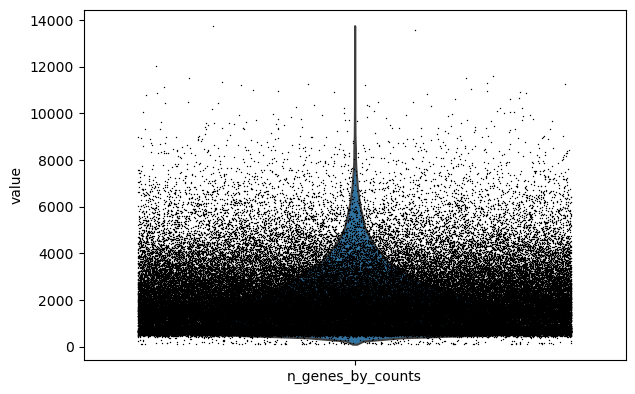

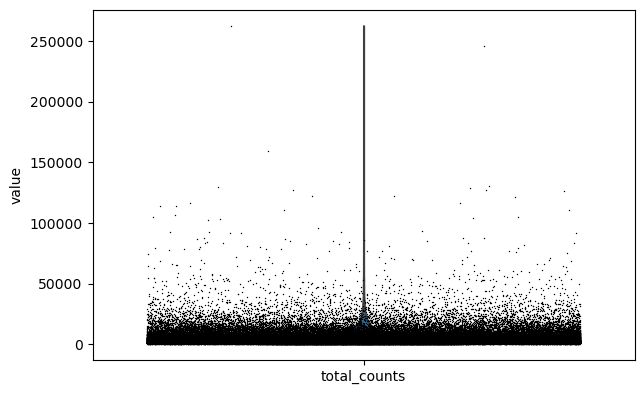

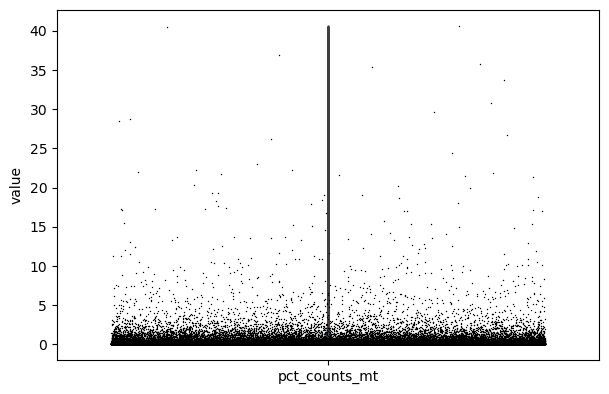

In [423]:
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4)
sc.pl.violin(adata, ['total_counts'], jitter=0.4)
sc.pl.violin(adata, ['pct_counts_mt'], jitter=0.4)

In [424]:
adata = adata[adata.obs.n_genes_by_counts < 6000,:]
adata = adata[adata.obs.total_counts < 30000,:]
adata = adata[adata.obs.pct_counts_mt < 5,:]

In [425]:
adata

View of AnnData object with n_obs × n_vars = 111684 × 43831
    obs: 'barcode', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_id', 'ensembl_id_version', 'external_gene_name', 'mt', 'external_gene_name_fix', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

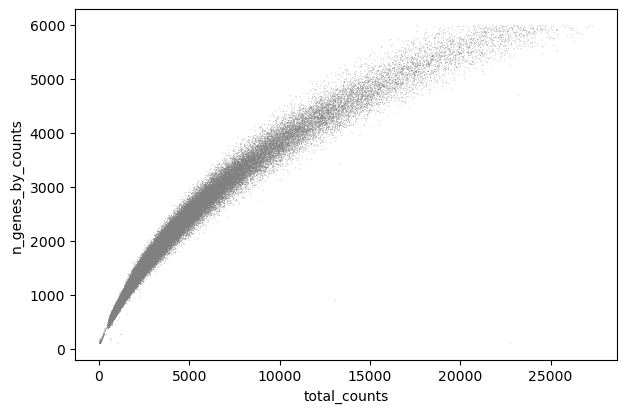

In [426]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [427]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/gpfs/commons/home/daknowles/.conda/envs/umap-learn/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.


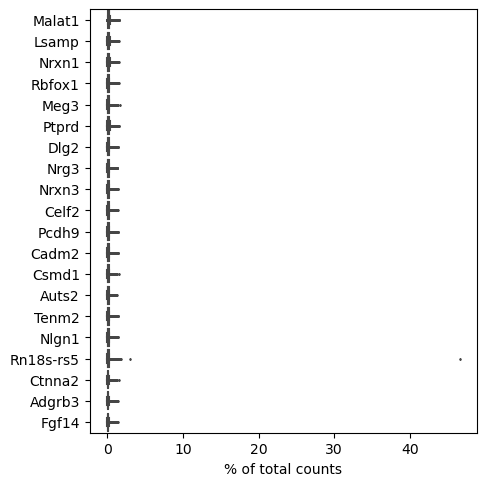

In [428]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [429]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)

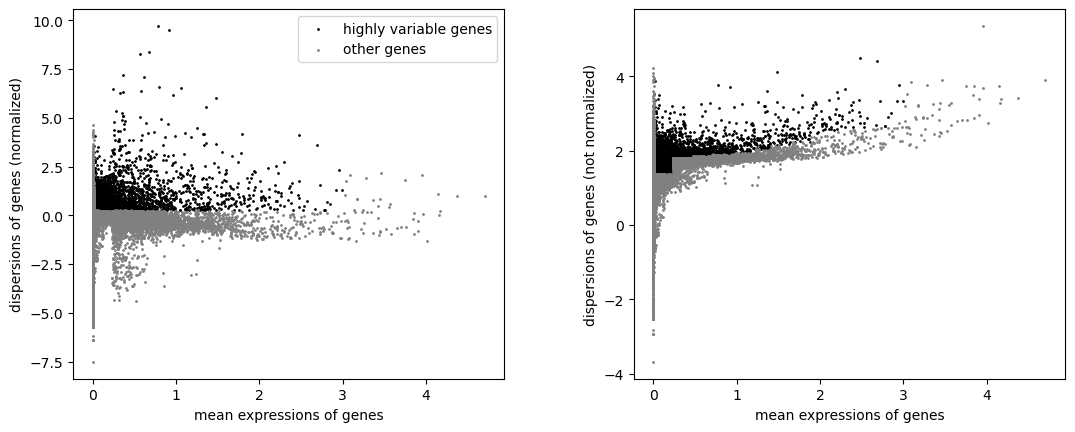

In [430]:
sc.pl.highly_variable_genes(adata)

In [431]:
adata.raw = adata

adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)

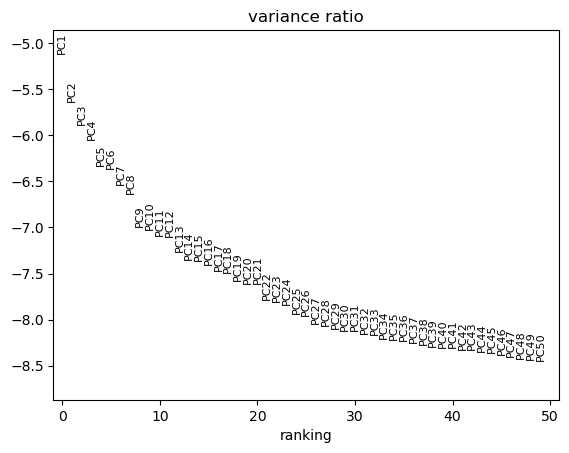

In [432]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [433]:
import umap

/gpfs/commons/home/daknowles/.conda/envs/umap-learn/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


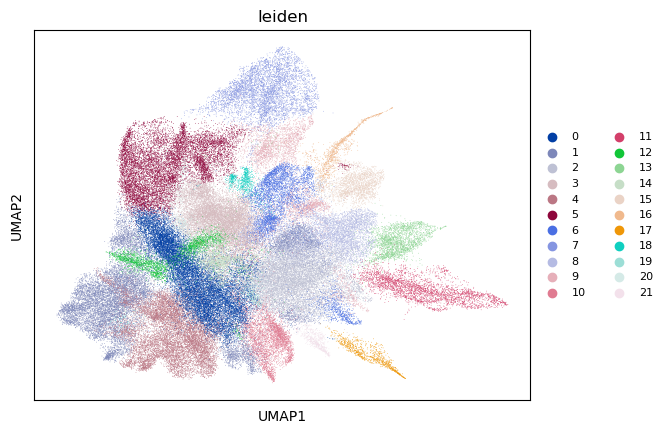

In [434]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=['leiden'], legend_fontsize=8, save='_leiden')

In [435]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

# The head function returns the top n genes per cluster
markers = pd.DataFrame(adata.uns['rank_genes_groups']['names'])


/gpfs/commons/home/daknowles/.conda/envs/umap-learn/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/gpfs/commons/home/daknowles/.conda/envs/umap-learn/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/gpfs/commons/home/daknowles/.conda/envs/umap-learn/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:399: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [436]:
known_markers = pd.read_csv("PanglaoDB_markers_27_Mar_2020.tsv.gz", sep = "\t")
known_markers.head()

,species,official gene symbol,cell type,nicknames,ubiquitousness index,product description,gene type,canonical marker,germ layer,organ,sensitivity_human,sensitivity_mouse,specificity_human,specificity_mouse
0,Mm Hs,CTRB1,Acinar cells,CTRB,0.017,chymotrypsinogen B1,protein-coding gene,1.0,Endoderm,Pancreas,1.000000,0.957143,0.000629,0.015920
1,Mm Hs,KLK1,Acinar cells,Klk6,0.013,kallikrein 1,protein-coding gene,1.0,Endoderm,Pancreas,0.833333,0.314286,0.005031,0.012826
2,Mm Hs,RBPJL,Acinar cells,RBP-L|SUHL|RBPSUHL,0.001,recombination signal binding protein for immun...,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.000000,0.000000,0.000000
3,Mm Hs,PTF1A,Acinar cells,PTF1-p48|bHLHa29,0.001,pancreas associated transcription factor 1a,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.157143,0.000629,0.000773
4,Mm,TRY4,Acinar cells,NaN,0.007,trypsin 4,protein coding gene,1.0,Endoderm,Pancreas,NaN,NaN,NaN,NaN


In [437]:
mouse_markers = known_markers[known_markers.species.str.contains("Mm")]
mouse_markers = mouse_markers.rename(columns={"official gene symbol" : "gene"})

mouse_markers

,species,gene,cell type,nicknames,ubiquitousness index,product description,gene type,canonical marker,germ layer,organ,sensitivity_human,sensitivity_mouse,specificity_human,specificity_mouse
0,Mm Hs,CTRB1,Acinar cells,CTRB,0.017,chymotrypsinogen B1,protein-coding gene,1.0,Endoderm,Pancreas,1.000000,0.957143,0.000629,0.015920
1,Mm Hs,KLK1,Acinar cells,Klk6,0.013,kallikrein 1,protein-coding gene,1.0,Endoderm,Pancreas,0.833333,0.314286,0.005031,0.012826
2,Mm Hs,RBPJL,Acinar cells,RBP-L|SUHL|RBPSUHL,0.001,recombination signal binding protein for immun...,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.000000,0.000000,0.000000
3,Mm Hs,PTF1A,Acinar cells,PTF1-p48|bHLHa29,0.001,pancreas associated transcription factor 1a,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.157143,0.000629,0.000773
4,Mm,TRY4,Acinar cells,NaN,0.007,trypsin 4,protein coding gene,1.0,Endoderm,Pancreas,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8281,Mm Hs,MYH11,Vascular smooth muscle cells,SMMHC|SMHC,0.015,myosin heavy chain 11,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,1.000000,0.016291,0.014697
8282,Mm Hs,PDGFRB,Vascular smooth muscle cells,JTK12|CD140b|PDGFR1|PDGFR,0.033,platelet derived growth factor receptor beta,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,0.750000,0.036341,0.033246
8283,Mm Hs,SEMA3D,Vascular smooth muscle cells,coll-2|Sema-Z2,0.005,semaphorin 3D,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,0.000000,0.001253,0.000000
8284,Mm Hs,TBX18,Vascular smooth muscle cells,NaN,0.004,T-box 18,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,0.000000,0.000313,0.000000


In [438]:
qvals = pd.DataFrame(adata.uns['rank_genes_groups']['pvals_adj'])
qvals

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000e+00,0.0,2.174565e-224,0.000000e+00,0.000000e+00,2.691980e-96,0.000000e+00,5.925102e-109,4.576466e-273
1,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000e+00,0.0,1.506233e-209,1.119622e-282,0.000000e+00,1.038474e-94,9.012186e-301,3.274873e-102,7.200365e-252
2,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.994072e-304,0.0,4.823117e-185,1.003011e-246,0.000000e+00,1.663047e-88,0.000000e+00,1.258265e-25,3.002036e-226
3,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.485671e-303,0.0,4.124141e-179,7.341552e-234,0.000000e+00,4.493979e-86,0.000000e+00,8.012013e-15,3.673621e-204
4,0.0,0.0,0.0,3.509724e-306,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.681502e-265,0.0,3.003701e-176,2.456586e-230,0.000000e+00,6.435776e-82,2.474479e-294,1.552753e-14,9.515412e-199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43826,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.058980e-89,0.0,1.787858e-84,6.734235e-80,1.211567e-157,6.932572e-268,0.000000e+00,0.000000e+00,5.533880e-138
43827,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.375811e-119,0.0,1.119825e-97,3.989611e-86,5.241857e-238,0.000000e+00,0.000000e+00,0.000000e+00,1.443039e-203
43828,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.654601e-129,0.0,1.297257e-106,4.544607e-99,6.041711e-203,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
43829,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.547399e-141,0.0,4.301997e-108,2.896533e-104,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.662574e-238


In [439]:
markers

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,Snhg14,Arpp21,Ptprz1,Meg3,Celf2,Meg3,Cadps2,Mbp,Npas3,Tnr,...,Nrxn3,Adam12,Ntng1,Dock2,Dnah12,Itpr1,Lncpint,Pfkp,Snhg14,Reln
1,Xist,Rbfox3,Npas3,Snhg11,Arpp21,Snhg11,Nfib,Tmeff2,Ptprz1,Sox6,...,Grip1,Ranbp3l,Rnf220,Inpp5d,Cfap299,Car8,Camk2a,Xist,Rn18s-rs5,Nav2
2,Tsix,Dlgap2,Gm3764,Ube3a,Ptprd,6330411D24Rik,Erbb4,Plp1,Malat1,Qki,...,Nxph1,Cped1,Tcf7l2,Elmo1,Cfap54,Ebf1,Sv2b,Grin2b,Filip1l,Ptprd
3,Pfkp,Celf2,Nfia,Nrg3,Dlg2,Snhg14,Chd7,Rnf220,Qki,Opcml,...,Erbb4,Bmp6,Zfhx3,Apbb1ip,Agbl4,Dab1,Sh3gl2,Ncam1,Cmss1,Tshz2
4,Dpp6,Phactr1,Mir99ahg,Cntnap2,Nrg3,Car10,Auts2,Pde4b,Slc4a4,Bcas1,...,Tcf4,Ptn,Mast4,Mertk,Dnah6,Ptprm,Mical2,Srgap1,Lars2,Fstl4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43826,Tnc,Hoxd3,Hoxd3,Rn18s-rs5,Zeb1,Tcf4,Mir100hg,Grin2b,Dlgap2,Tenm4,...,Hoxd3,Plp1,Hoxaas3,Slc38a5,Foxq1,Hoxb5os,Xist,4930509J09Rik,Cldn14,Hoxd3
43827,Mobp,Hoxc5,Plp1,Filip1l,Erbb4,Msra,Plxna4,Celf2,Cacna1b,Grin2b,...,Hoxc6,Cldn14,Mobp,Cldn14,2210411M09Rik,5730585A16Rik,Lrrn3,Gm38353,Apcdd1,Tie1
43828,Atp1a2,Gm26992,Mag,Cmss1,Msi2,Dlx6os1,Xylt1,Gm26992,Rian,Rian,...,Arpp21,Tmem212,Hoxd4,Ermn,Opalin,Hoxd4,Hoxd4,Gm21954,Gjc3,Cd93
43829,Slc4a4,Tsix,Hoxc5,Lars2,Zfp521,Celf2,Ldb2,Tsix,Snhg11,Snhg11,...,Mag,Mag,Hoxd3,C130074G19Rik,Atg9b,Hoxd3,4930415C11Rik,Lrrtm3,Paqr5,Hoxc5


In [440]:
for i in range(qvals.shape[1]):
    temp = pd.DataFrame({"gene":markers.iloc[:,i], "qval":qvals.iloc[:,i]})
    temp = temp.merge(mouse_markers, on = "gene", how = "inner")
    print(i)
    print(temp[temp.qval < 0.05].sort_values("qval")["cell type"])

0
0             Endothelial cells
1                       T cells
2                T memory cells
3                    Mast cells
4             Mesothelial cells
5             Endothelial cells
6       Peritubular myoid cells
18    Undefined placental cells
Name: cell type, dtype: object
1
18    Undefined placental cells
0             Endothelial cells
1       Peritubular myoid cells
2             Endothelial cells
16                   Mast cells
17            Mesothelial cells
Name: cell type, dtype: object
2
0             Endothelial cells
1                       T cells
2                T memory cells
3                    Mast cells
4             Mesothelial cells
18    Undefined placental cells
5                       T cells
Name: cell type, dtype: object
3
18            Endothelial cells
17    Undefined placental cells
16                   Adipocytes
15                    Platelets
13                      T cells
14               T memory cells
12                      T cells
11 

## 1

In [ ]:
i = 0
sig = qvals.iloc[:,i] == 0. 
markers.iloc[:,i][sig]

In [ ]:
sig.mean()

In [ ]:
adata.obs.leiden.unique()

In [ ]:
adata.var

In [ ]:
import matplotlib.pyplot as plt
adata.uns['rank_genes_groups']['pvals_adj'][0]

In [ ]:
adata.var